In [1]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta,time
from scipy import stats
import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import sklearn.metrics as metrics

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent

    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [5]:
userInputData = loadDataFromFile("UserPrevious experiments-preprocessed")
timeSeriesData_BIG = loadDataFromFile("Data:Previous experiments-preprocessed")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 79 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/UserPrevious experiments-preprocessed.json
/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 199098 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/Data:Previous experiments-preprocessed.json


In [6]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion
0,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,1751328000000,1751383639000,1751386484000,2845000,2543000,2543,302000
1,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,1751414400000,1751470970000,1751472292000,1322000,1000000,1000,322000
2,InsertingSourcePollutant,on,None,None,0.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,1751500800000,1751545825000,1751546731000,906000,248000,248,658000
3,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.8,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,1751500800000,1751557900000,1751558351000,451000,88000,88,363000
4,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.3,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,1752019200000,1752087704000,1752089270000,1566000,1056000,1056,510000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.6,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,1756166400000,1756213347000,1756214628000,1281000,424000,424,857000
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,1756166400000,1756215406000,1756216384000,978000,317000,317,661000
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.0,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,1756166400000,1756225781000,1756228276000,2495000,1171000,1171,1324000
77,InsertingSourcePollutant,on,None,None,0.7,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,1756166400000,1756230988000,1756233200000,2212000,1719000,1719,493000


In [7]:
timeSeriesData_BIG

,keys,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds
0,0,0,Id=1:BME680:breathVocEquivalent,1.476941,False,False,1751383639000,0
1,0,0,Id=2:BME680:breathVocEquivalent,1.430472,False,True,1751383639000,0
2,0,1000,Id=1:BME680:breathVocEquivalent,1.473184,False,False,1751383640000,1
3,0,1000,Id=2:BME680:breathVocEquivalent,1.434089,False,False,1751383640000,1
4,0,2000,Id=1:BME680:breathVocEquivalent,1.469428,False,True,1751383641000,2
...,...,...,...,...,...,...,...,...
199093,78,761000,Id=2:BME680:breathVocEquivalent,513.575400,True,True,1756234548000,761
199094,78,761000,Id=0:BME680:breathVocEquivalent,25.242983,True,False,1756234548000,761
199095,78,762000,Id=1:BME680:breathVocEquivalent,81.105730,True,False,1756234549000,762
199096,78,762000,Id=2:BME680:breathVocEquivalent,513.575400,True,False,1756234549000,762


In [8]:
# Convert back to timedelta
timeSeriesData_BIG['timestamp'] = pd.to_timedelta(timeSeriesData_BIG['timestamp'], unit='ms')

# Convert back to datetime

timeSeriesData_BIG ["datetime_timestamp"]= timeSeriesData_BIG['datetime_timestamp'].transform(
    lambda x: pd.to_datetime(x, unit='ms')
)
# Split back into dict
dict_of_timeseries = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG.groupby("keys")}

In [9]:
dict_of_timeseries[0]

,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds
0,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,1.476941,False,False,2025-07-01 15:27:19,0
1,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,1.430472,False,True,2025-07-01 15:27:19,0
2,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,1.473184,False,False,2025-07-01 15:27:20,1
3,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,1.434089,False,False,2025-07-01 15:27:20,1
4,0 days 00:00:02,Id=1:BME680:breathVocEquivalent,1.469428,False,True,2025-07-01 15:27:21,2
...,...,...,...,...,...,...,...
5687,0 days 00:47:23,Id=2:BME680:breathVocEquivalent,9.453519,True,False,2025-07-01 16:14:42,2843
5688,0 days 00:47:24,Id=1:BME680:breathVocEquivalent,5.150744,True,False,2025-07-01 16:14:43,2844
5689,0 days 00:47:24,Id=2:BME680:breathVocEquivalent,9.469537,True,True,2025-07-01 16:14:43,2844
5690,0 days 00:47:25,Id=1:BME680:breathVocEquivalent,5.150744,True,False,2025-07-01 16:14:44,2845


In [10]:
columns_datetime= [
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment', ]
columns_timedelta = ['time taken total',
       'timestamp InsertingSource timedelta',
       'time taken after insertion']

userInputData.loc[:,columns_datetime] = userInputData.loc[:,columns_datetime].apply(lambda x:pd.to_datetime(x, unit='ms'))
userInputData.loc[:,columns_timedelta] = userInputData.loc[:,columns_timedelta].apply(lambda x:pd.to_timedelta(x, unit='ms'))

/tmp/ipykernel_5655/207649817.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<DatetimeArray>
['2025-07-01 00:00:00', '2025-07-02 00:00:00', '2025-07-03 00:00:00',
 '2025-07-03 00:00:00', '2025-07-09 00:00:00', '2025-07-12 00:00:00',
 '2025-07-14 00:00:00', '2025-07-19 00:00:00', '2025-07-19 00:00:00',
 '2025-07-19 00:00:00', '2025-07-19 00:00:00', '2025-07-19 00:00:00',
 '2025-07-19 00:00:00', '2025-07-20 00:00:00', '2025-07-20 00:00:00',
 '2025-07-20 00:00:00', '2025-07-20 00:00:00', '2025-07-20 00:00:00',
 '2025-07-20 00:00:00', '2025-07-20 00:00:00', '2025-07-20 00:00:00',
 '2025-07-20 00:00:00', '2025-07-20 00:00:00', '2025-07-20 00:00:00',
 '2025-07-20 00:00:00', '2025-07-20 00:00:00', '2025-07-21 00:00:00',
 '2025-07-21 00:00:00', '2025-07-21 00:00:00', '2025-07-21 00:00:00',
 '2025-07-21 00:00:00', '2025-07-21 00:00:00', '2025-07-21 00:00:00',
 '2025-07-21 00:00:00', '2025-07-22 00:00:00', '2025-07-22 0

In [11]:
#remove all 
timeSeriesData_BIG_check_Interpolation = timeSeriesData_BIG.copy()
print(timeSeriesData_BIG_check_Interpolation.columns)

timeSeriesData_BIG_check_Interpolation["VOC given real values"] = timeSeriesData_BIG_check_Interpolation["VOC"]
timeSeriesData_BIG_check_Interpolation["VOC given real values"] = timeSeriesData_BIG_check_Interpolation["VOC given real values"].mask(timeSeriesData_BIG_check_Interpolation["original_value"]==False)
#timeSeriesData_BIG_check_Interpolation["points to check interpolation"] = timeSeriesData_BIG_check_Interpolation["VOC"]
#timeSeriesData_BIG_check_Interpolation["points to check interpolation"] = timeSeriesData_BIG_check_Interpolation["points to check interpolation"].mask(timeSeriesData_BIG_check_Interpolation["kept to test interpolation"] == False)
timeSeriesData_BIG_check_Interpolation["original_value_cum_sum"] = timeSeriesData_BIG_check_Interpolation.groupby(["keys","sensors"])["original_value"].transform("cumsum")
#make every second appear of a true given value null also 
#mask = (timeSeriesData_BIG_check_Interpolation["original_value"] == True) & (timeSeriesData_BIG_check_Interpolation["original_value_cum_sum"] % 2 == 0)
#timeSeriesData_BIG_check_Interpolation.loc[:,"kept to test interpolation"] =timeSeriesData_BIG_check_Interpolation.apply(lambda x: True if ((x["original_value"] == True) & (x["original_value_cum_sum"] % 2 == 1)) else False,axis=1)
timeSeriesData_BIG_check_Interpolation.head(20)

Index(['keys', 'timestamp', 'sensors', 'VOC', 'after_insertion',
       'original_value', 'datetime_timestamp', 'seconds'],
      dtype='object')


,keys,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds,VOC given real values,original_value_cum_sum
0,0,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,1.476941,False,False,2025-07-01 15:27:19,0,NaN,0
1,0,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,1.430472,False,True,2025-07-01 15:27:19,0,1.430472,1
2,0,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,1.473184,False,False,2025-07-01 15:27:20,1,NaN,0
3,0,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,1.434089,False,False,2025-07-01 15:27:20,1,NaN,1
4,0,0 days 00:00:02,Id=1:BME680:breathVocEquivalent,1.469428,False,True,2025-07-01 15:27:21,2,1.469428,1
5,0,0 days 00:00:02,Id=2:BME680:breathVocEquivalent,1.437705,False,False,2025-07-01 15:27:21,2,NaN,1
6,0,0 days 00:00:03,Id=1:BME680:breathVocEquivalent,1.471700,False,False,2025-07-01 15:27:22,3,NaN,1
7,0,0 days 00:00:03,Id=2:BME680:breathVocEquivalent,1.441322,False,True,2025-07-01 15:27:22,3,1.441322,2
8,0,0 days 00:00:04,Id=1:BME680:breathVocEquivalent,1.473971,False,False,2025-07-01 15:27:23,4,NaN,1
9,0,0 days 00:00:04,Id=2:BME680:breathVocEquivalent,1.444173,False,False,2025-07-01 15:27:23,4,NaN,2


In [12]:
# Split back into dict
dict_of_timeseries_inter = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG_check_Interpolation.groupby("keys")}

In [13]:
dict_of_timeseries_inter[65]

,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds,VOC given real values,original_value_cum_sum
0,0 days 00:00:00,Id=0:BME680:breathVocEquivalent,3.550925,False,False,2025-08-24 13:23:55,0,NaN,0
1,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,1.056772,False,False,2025-08-24 13:23:55,0,NaN,0
2,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,3.841503,False,True,2025-08-24 13:23:55,0,3.841503,1
3,0 days 00:00:01,Id=0:BME680:breathVocEquivalent,3.544600,False,True,2025-08-24 13:23:56,1,3.544600,1
4,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,1.057122,False,False,2025-08-24 13:23:56,1,NaN,0
...,...,...,...,...,...,...,...,...,...
2005,0 days 00:11:08,Id=1:BME680:breathVocEquivalent,1.141197,True,True,2025-08-24 13:35:03,668,1.141197,223
2006,0 days 00:11:08,Id=2:BME680:breathVocEquivalent,4.153985,True,False,2025-08-24 13:35:03,668,NaN,223
2007,0 days 00:11:09,Id=0:BME680:breathVocEquivalent,4.081968,True,False,2025-08-24 13:35:04,669,NaN,223
2008,0 days 00:11:09,Id=1:BME680:breathVocEquivalent,1.141197,True,False,2025-08-24 13:35:04,669,NaN,223


<Axes: xlabel='seconds', ylabel='VOC'>

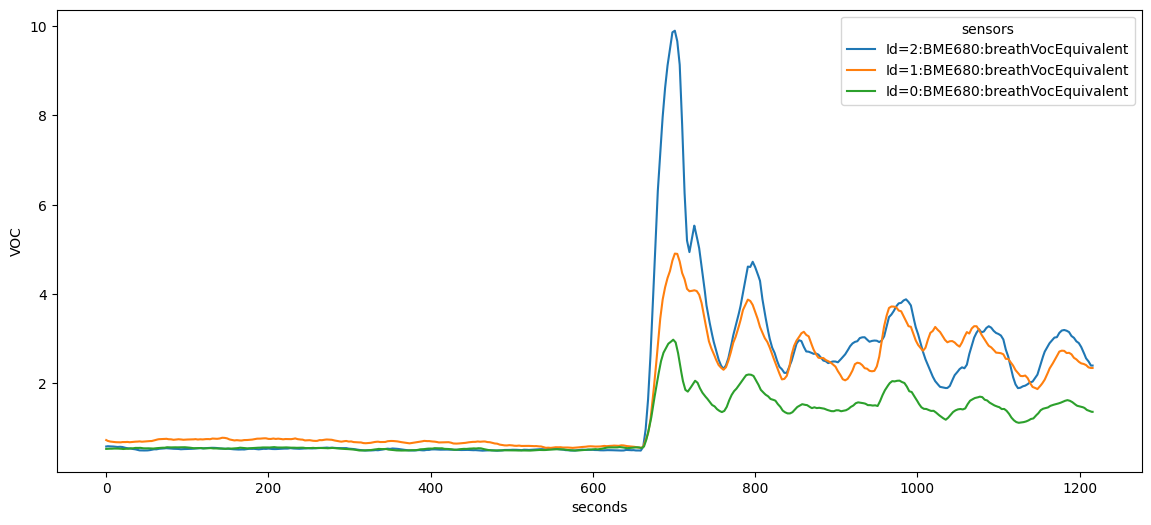

In [14]:
plt.figure(figsize=(14, 6))

sns.lineplot(data = dict_of_timeseries_inter[71],x="seconds" ,y="VOC" ,hue="sensors")

<Axes: xlabel='seconds', ylabel='VOC given real values'>

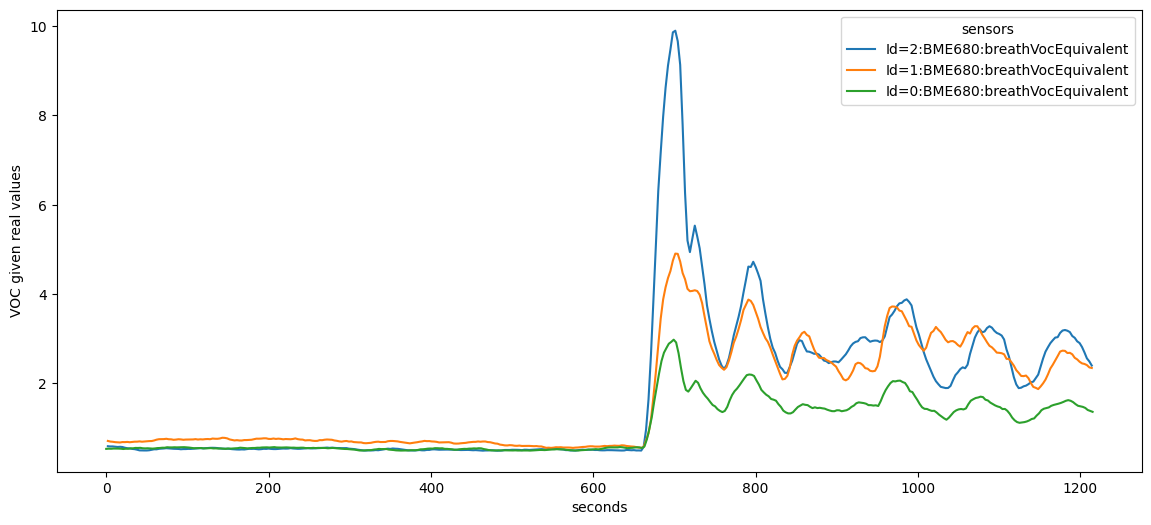

In [15]:
plt.figure(figsize=(14, 6))

sns.lineplot(data = dict_of_timeseries_inter[71],x="seconds" ,y="VOC given real values" ,hue="sensors")

In [29]:
def insertColumnsTointerpolation_differences(interpolation_differences,method):
    columns= []
    sensors_names = ["Id=0:BME680:breathVocEquivalent","Id=1:BME680:breathVocEquivalent","Id=2:BME680:breathVocEquivalent"]
    columns.extend(["MSE-" + x +"-"+method for x in sensors_names])
    columns.extend(["MSE-" + "3 points missing-" + x +"-"+method for x in sensors_names])
    columns.extend(["MAE-" + x +"-"+method for x in sensors_names])
    columns.extend(["MSE-" + "3 points missing-" + x +"-"+method for x in sensors_names])
  #  columns.extend(["R2-" + x +"-"+method for x in sensors_names])
    for column in columns:
        interpolation_differences[column] = np.nan
    return interpolation_differences

In [30]:
def checkInterpolationMethod(dict_of_timeseries_inter,interpolation_differences,method):
    insertColumnsTointerpolation_differences(interpolation_differences,method)
    #print(interpolation_differences)

    for index, row in userInputData.iterrows():
        
        experiment_df = dict_of_timeseries_inter[index]
        #print(experiment_df)
        sensors = experiment_df["sensors"].unique()
        target_column = "VOC-" +method
        target_column_3_points_missing = target_column + "-3 points missing"
        experiment_df[target_column] = experiment_df.apply(lambda x:x["VOC given real values"] if (x["original_value_cum_sum"]% 2 == 0) else np.nan,axis=1)
        three_points_missings = experiment_df.loc[experiment_df["VOC given real values"].notna()].copy()        
        three_points_missings[target_column_3_points_missing]  =  three_points_missings.apply(lambda x:x["VOC given real values"] if (x["original_value_cum_sum"]% 3 == 0) else np.nan,axis=1)
        for sensor in sensors:
            mask = (experiment_df["sensors"] == sensor)
          #  print(experiment_df.loc[mask,:].shape)
            experiment_df.loc[mask,target_column] = experiment_df.loc[mask,target_column].interpolate(method = method)
            three_points_missings.loc[mask,target_column_3_points_missing] = three_points_missings.loc[mask,target_column_3_points_missing].interpolate(method = method)
            dropped_df = experiment_df.loc[mask,:].dropna()
          #  print(dropped_df.shape)
            dropped_df_three_points_missings = experiment_df.loc[mask,:].dropna()

            mae = metrics.mean_absolute_error(dropped_df.loc[mask,"VOC given real values"], dropped_df.loc[mask,target_column])
            column_to_save = "MAE-"+sensor +"-"+method
            interpolation_differences.at[index,column_to_save] = mae
            mse = metrics.mean_squared_error(dropped_df.loc[mask,"VOC given real values"], dropped_df.loc[mask,target_column])
            column_to_save = "MSE-"+sensor +"-"+method
            interpolation_differences.at[index,column_to_save] = mse

            #############################
            three_points_missings.loc[mask,target_column_3_points_missing] = three_points_missings.loc[mask,target_column_3_points_missing].interpolate(method = method)
            dropped_df_three_points_missings = three_points_missings.loc[mask,:].dropna()

            
            mae = metrics.mean_absolute_error(dropped_df_three_points_missings.loc[mask,"VOC given real values"].dropna(), dropped_df_three_points_missings.loc[mask,target_column_3_points_missing].dropna())
            column_to_save = "MAE-"+ "3 points missing-" +sensor +"-"+method
            interpolation_differences.at[index,column_to_save] = mae
            mse = metrics.mean_squared_error(dropped_df_three_points_missings.loc[mask,"VOC given real values"].dropna(), dropped_df_three_points_missings.loc[mask,target_column_3_points_missing].dropna())
            column_to_save = "MSE-"+"3 points missing-" +sensor +"-"+method
            interpolation_differences.at[index,column_to_save] = mse
            
        dict_of_timeseries_inter[index] = experiment_df
    return dict_of_timeseries_inter   

In [31]:
# Split back into dict
dict_of_timeseries_inter = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG_check_Interpolation.groupby("keys")}
interpolation_differences = pd.DataFrame(index = np.arange(userInputData.shape[0]))
dict_of_timeseries_inter = checkInterpolationMethod(dict_of_timeseries_inter,interpolation_differences,"linear")
dict_of_timeseries_inter = checkInterpolationMethod(dict_of_timeseries_inter,interpolation_differences,"cubicspline")

In [32]:
interpolation_differences

,MSE-Id=0:BME680:breathVocEquivalent-linear,MSE-Id=1:BME680:breathVocEquivalent-linear,MSE-Id=2:BME680:breathVocEquivalent-linear,MSE-3 points missing-Id=0:BME680:breathVocEquivalent-linear,MSE-3 points missing-Id=1:BME680:breathVocEquivalent-linear,MSE-3 points missing-Id=2:BME680:breathVocEquivalent-linear,MAE-Id=0:BME680:breathVocEquivalent-linear,MAE-Id=1:BME680:breathVocEquivalent-linear,MAE-Id=2:BME680:breathVocEquivalent-linear,MAE-3 points missing-Id=1:BME680:breathVocEquivalent-linear,MAE-3 points missing-Id=2:BME680:breathVocEquivalent-linear,MAE-3 points missing-Id=0:BME680:breathVocEquivalent-linear,MSE-Id=0:BME680:breathVocEquivalent-cubicspline,MSE-Id=1:BME680:breathVocEquivalent-cubicspline,MSE-Id=2:BME680:breathVocEquivalent-cubicspline,MSE-3 points missing-Id=0:BME680:breathVocEquivalent-cubicspline,MSE-3 points missing-Id=1:BME680:breathVocEquivalent-cubicspline,MSE-3 points missing-Id=2:BME680:breathVocEquivalent-cubicspline,MAE-Id=0:BME680:breathVocEquivalent-cubicspline,MAE-Id=1:BME680:breathVocEquivalent-cubicspline,MAE-Id=2:BME680:breathVocEquivalent-cubicspline,MAE-3 points missing-Id=1:BME680:breathVocEquivalent-cubicspline,MAE-3 points missing-Id=2:BME680:breathVocEquivalent-cubicspline,MAE-3 points missing-Id=0:BME680:breathVocEquivalent-cubicspline
0,NaN,0.000030,0.000410,NaN,0.000062,0.000946,NaN,0.002923,0.010411,0.004788,0.016715,NaN,NaN,0.000030,0.000476,NaN,0.000057,0.000968,NaN,0.002947,0.011062,0.004549,0.017214,NaN
1,NaN,0.000011,0.000007,NaN,0.000033,0.000009,NaN,0.001482,0.001301,0.002548,0.001777,NaN,NaN,0.000007,0.000006,NaN,0.000013,0.000010,NaN,0.001366,0.001302,0.002142,0.001841,NaN
2,NaN,0.000068,0.017438,NaN,0.000128,0.015434,NaN,0.004684,0.029709,0.007245,0.045861,NaN,NaN,0.000071,0.016817,NaN,0.000113,0.014687,NaN,0.004957,0.024679,0.006869,0.038583,NaN
3,NaN,0.000017,0.008530,NaN,0.000028,0.025409,NaN,0.002175,0.039105,0.002981,0.074512,NaN,NaN,0.000035,0.008135,NaN,0.000030,0.020918,NaN,0.002440,0.036816,0.003380,0.067493,NaN
4,NaN,0.000004,0.000014,NaN,0.000009,0.000032,NaN,0.001111,0.002077,0.001822,0.003403,NaN,NaN,0.000004,0.000017,NaN,0.000008,0.000035,NaN,0.001104,0.002271,0.001861,0.003471,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,0.001001,0.000081,0.000064,0.002489,0.000504,0.000102,0.015308,0.003926,0.003829,0.009864,0.005612,0.027407,0.000743,0.000070,0.000062,0.001756,0.000241,0.000087,0.014041,0.003939,0.003591,0.007875,0.005095,0.024091
75,0.001561,0.000217,0.000068,0.003389,0.000466,0.000104,0.019506,0.007143,0.004263,0.012108,0.006082,0.033489,0.001380,0.000175,0.000051,0.002385,0.000420,0.000078,0.018697,0.006718,0.003722,0.011463,0.005513,0.027914
76,0.042158,0.265349,2.611864,0.105338,1.522237,10.013200,0.049764,0.090094,0.200152,0.217657,0.474403,0.097820,0.011818,0.022033,0.529136,0.018043,0.183456,4.096975,0.035156,0.043476,0.110793,0.091687,0.353416,0.052077
77,0.000306,0.000965,0.000507,0.000553,0.001684,0.001019,0.009829,0.014347,0.012508,0.022647,0.020756,0.015399,0.000332,0.000708,0.000520,0.000607,0.001241,0.001087,0.010048,0.013734,0.012830,0.021896,0.021119,0.015923


In [33]:
#remove outliers
Q3_5_interpolation_differences = interpolation_differences.quantile(0.95)

interpolation_differences.where(interpolation_differences<Q3_5_interpolation_differences).mean()

MSE-Id=0:BME680:breathVocEquivalent-linear                          0.015796
MSE-Id=1:BME680:breathVocEquivalent-linear                          0.000336
MSE-Id=2:BME680:breathVocEquivalent-linear                          0.389027
MSE-3 points missing-Id=0:BME680:breathVocEquivalent-linear         0.159972
MSE-3 points missing-Id=1:BME680:breathVocEquivalent-linear         0.001387
MSE-3 points missing-Id=2:BME680:breathVocEquivalent-linear         2.798706
MAE-Id=0:BME680:breathVocEquivalent-linear                          0.016579
MAE-Id=1:BME680:breathVocEquivalent-linear                          0.003464
MAE-Id=2:BME680:breathVocEquivalent-linear                          0.013476
MAE-3 points missing-Id=1:BME680:breathVocEquivalent-linear         0.006003
MAE-3 points missing-Id=2:BME680:breathVocEquivalent-linear         0.028106
MAE-3 points missing-Id=0:BME680:breathVocEquivalent-linear         0.039660
MSE-Id=0:BME680:breathVocEquivalent-cubicspline                     0.005166

In [37]:
dict_of_timeseries_inter[71]

,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds,VOC given real values,original_value_cum_sum,VOC-linear,VOC-cubicspline
0,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,0.589110,False,False,2025-08-24 22:23:49,0,NaN,0,NaN,NaN
1,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,0.733060,False,False,2025-08-24 22:23:49,0,NaN,0,NaN,NaN
2,0 days 00:00:00,Id=0:BME680:breathVocEquivalent,0.535803,False,True,2025-08-24 22:23:49,0,0.535803,1,NaN,NaN
3,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,0.592147,False,False,2025-08-24 22:23:50,1,NaN,0,NaN,NaN
4,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,0.723292,False,False,2025-08-24 22:23:50,1,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3646,0 days 00:20:15,Id=1:BME680:breathVocEquivalent,2.346797,True,False,2025-08-24 22:44:04,1215,NaN,405,2.360010,2.253319
3647,0 days 00:20:15,Id=0:BME680:breathVocEquivalent,1.365091,True,True,2025-08-24 22:44:04,1215,1.365091,406,1.365091,1.365091
3648,0 days 00:20:16,Id=2:BME680:breathVocEquivalent,2.401184,True,False,2025-08-24 22:44:05,1216,NaN,405,2.493991,2.453493
3649,0 days 00:20:16,Id=1:BME680:breathVocEquivalent,2.346797,True,False,2025-08-24 22:44:05,1216,NaN,405,2.360010,2.216325


<Axes: xlabel='seconds', ylabel='VOC'>

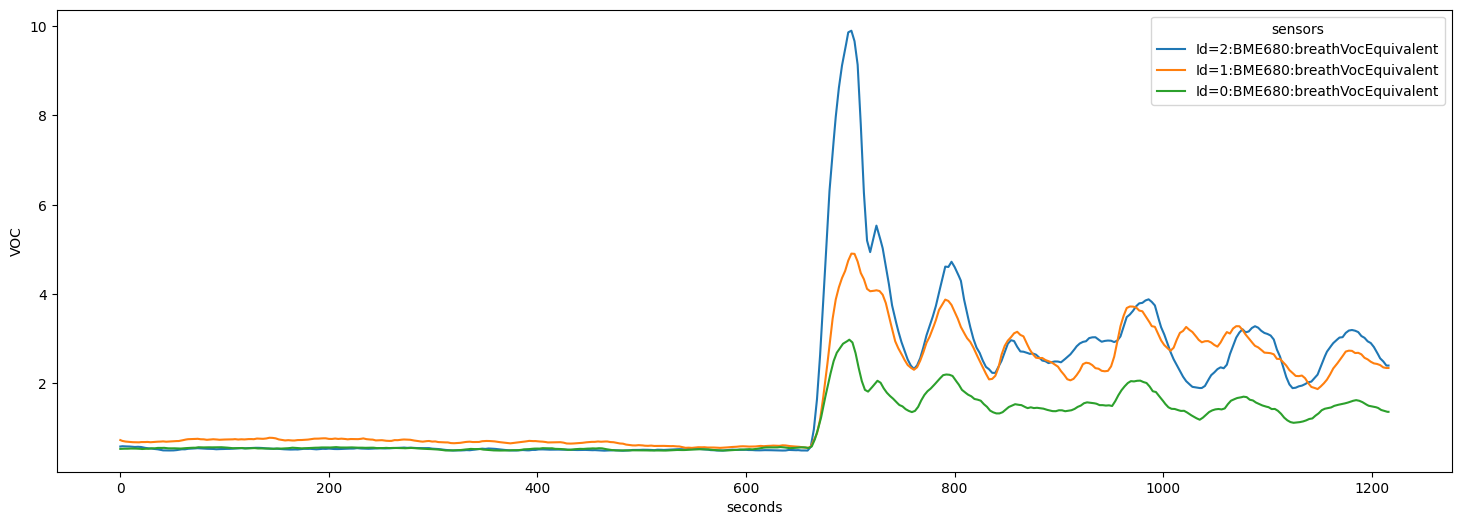

In [41]:
plt.figure(figsize=(18, 6))

sns.lineplot(data = dict_of_timeseries_inter[71],x="seconds" ,y="VOC" ,hue="sensors")

<Axes: xlabel='seconds', ylabel='VOC-linear'>

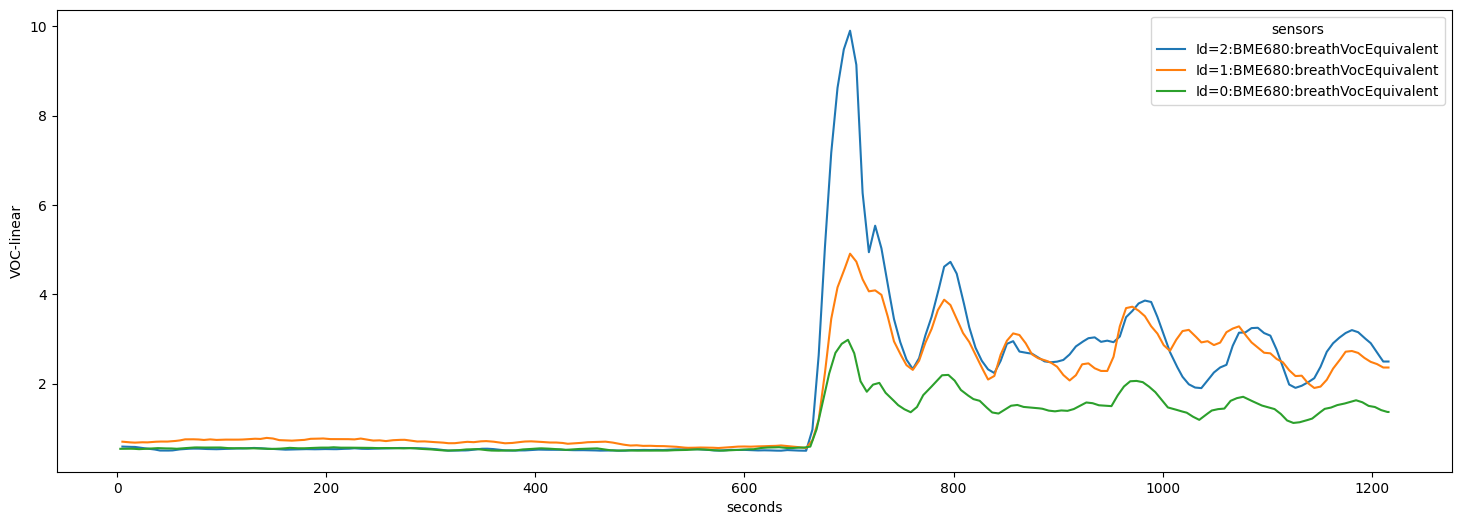

In [42]:
plt.figure(figsize=(18, 6))

sns.lineplot(data = dict_of_timeseries_inter[71],x="seconds" ,y="VOC-linear" ,hue="sensors")

<Axes: xlabel='seconds', ylabel='VOC-cubicspline'>

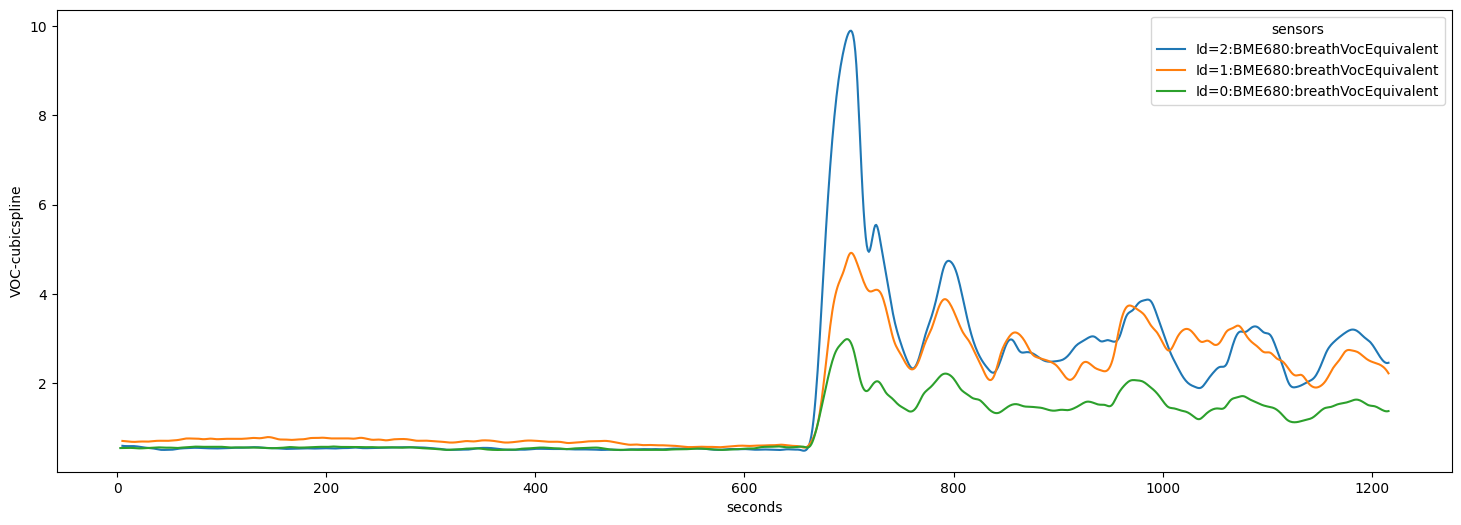

In [43]:
plt.figure(figsize=(18, 6))

sns.lineplot(data = dict_of_timeseries_inter[71],x="seconds" ,y="VOC-cubicspline" ,hue="sensors")